In [1]:
# This is a generic code for looking at the continous HOBO data against the manual field measurements for one Bell Field Piezometer. Replace all of the "placeholders" with the files/parameters that you are looking for.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# The code chunk below installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells

In [4]:
# pip install hampel

In [5]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [6]:
import os # Allows python to communicate directly with the computer's operating system

In [7]:
# Reading the continuous data
spring = pd.read_csv("Spring_current.csv")
spring = spring.dropna()
spring["Date-Time"] = pd.to_datetime(spring["Date-Time"]) #Date-Time (CST/CDT) is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
spring.index = pd.DatetimeIndex(spring["Date-Time"]) # This makes the the datetime column a 'datetime index', which allows us to reassign the correct dates after passing the data through the hampel filter.


In [8]:
spring.head()

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
Date-Time,,,,,,
2026-07-01 16:45:00,2026-07-01 16:45:00,13.546818,461.373901,607.484009,0.288418,299.893036
2026-07-01 17:00:00,2026-07-01 17:00:00,12.848606,449.727692,603.806580,0.285873,292.322998
2026-07-01 17:15:00,2026-07-01 17:15:00,12.685734,447.230682,603.224182,0.285407,290.699921
2026-07-01 17:30:00,2026-07-01 17:30:00,12.565006,445.539062,603.004578,0.285163,289.600372
2026-07-01 17:45:00,2026-07-01 17:45:00,12.522739,452.933624,613.749878,0.290354,294.406830


In [9]:
# the hampel filter uses a running average to compute outliers in time-dependent data. Instead of dropping outliers, it replaces them with the local average. 
springfilt = hampel(spring["Temperature"], window_size=6, n_sigma=1.5)

In [10]:
# the hampel result has an internal index that must be stripped away to add the data back into our data frame. I convert it to a NumPy array, and then into a DataFrame with the original datetime index. (Thanks to Goodgle Gemini)
springfilt = pd.DataFrame(springfilt.filtered_data.to_numpy(), index=spring.index)

In [11]:
spring["FilteredTemp"] = springfilt

In [16]:
#reading the manual data
springman = pd.read_csv("Well_Sampling_Data_ALL - Spring.csv", index_col=False) #Well_Sampling_Data_P1.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
springman["Date"] = pd.to_datetime(springman["Date"]) #converts the manual date-time values to pandas datetime format. 

In [17]:
springman.head()

,Date,Temp (C),SPC,Cond,TDS (ppt)
0,2026-07-14,11.8,725,541,0.4
1,2026-07-21,11.7,760,569,0.4


In [37]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDamTemp.csv")
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])

In [38]:
weatherdf

,Date,MeanTempF,MeanTempC
0,2024-07-01,64.0,17.777778
1,2024-07-02,67.5,19.722222
2,2024-07-03,66.5,19.166667
3,2024-07-04,74.5,23.611111
4,2024-07-05,66.0,18.888889
...,...,...,...
749,2026-07-20,77.0,25.000000
750,2026-07-21,80.5,26.944444
751,2026-07-22,70.0,21.111111
752,2026-07-23,64.5,18.055556


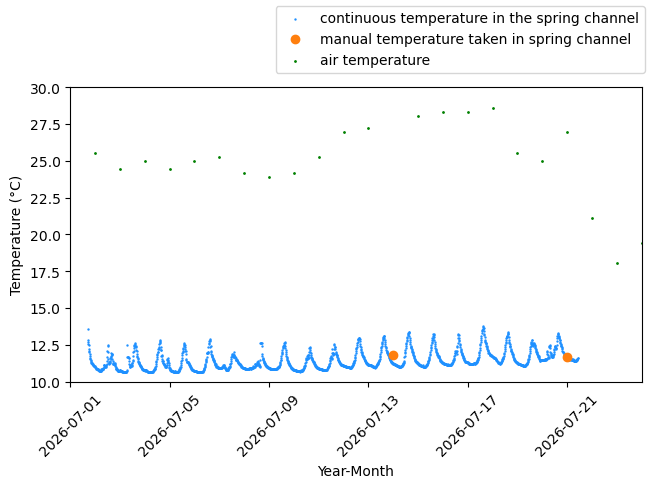

In [44]:
#creating the plot
springman.columns = springman.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  


fig, ax = plt.subplots(layout='constrained')
#ax.plot(date1, filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.scatter(spring.index, spring.FilteredTemp, color="dodgerblue", s = 0.5, label = "continuous temperature in the spring channel")
ax.plot(springman.Date, springman.loc[:,"Temp (C)"], 'o', color = "tab:orange", label = "manual temperature taken in spring channel") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime), mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"], and manual temperature at top before pumping (which you should replace with the name of the data for the legend). 
ax.scatter(weatherdf.Date, weatherdf.MeanTempC, color = "green", s = 1, label = "air temperature")
# ax.plot(springdate, C1filteredhobo, color = "xkcd:light grey green", label = "C1 continuous temperature data")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
# plt.ylim((0, 20))
plt.xlim((pd.to_datetime("2026-07-01"), pd.to_datetime("2026-07-24")))
plt.ylim((10, 30))

fig.legend(loc='outside upper right') #this line puts legend outside of graph, squishes it down, but is not awful. Run with # in front to see the graph at its default dimensions.

plt.show()

In [ ]:
#P1 SPC

In [46]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P1filteredSPC = hampel(spring["Specific Conductivity"], window_size=6, n_sigma=1.5)
P1filteredSPC = pd.DataFrame(P1filteredSPC.filtered_data.to_numpy(), index=spring.index)
spring["FilteredSPC"] = P1filteredSPC

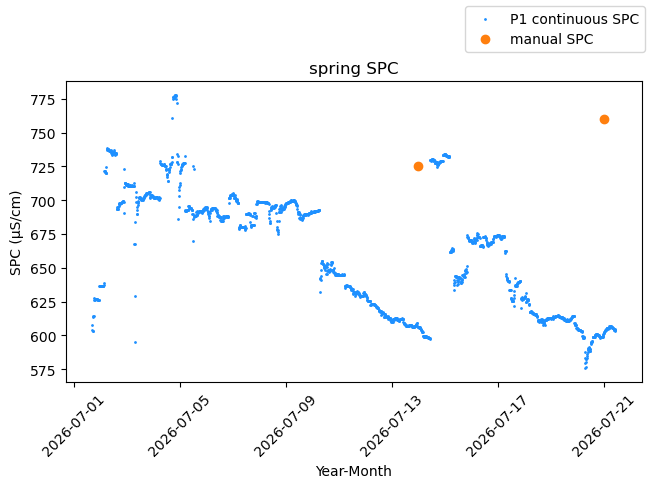

In [52]:

P1hobodate = spring["Date-Time"]
P1slicedhobodate = P1hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(spring.index, spring.FilteredSPC, color="dodgerblue", s=1, label = "P1 continuous SPC")
ax.plot(springman.Date, springman.loc[:,"SPC"], 'o', color = "tab:orange", label = "manual SPC ")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("spring SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()